# Analisando Imagens com a API do Gemini

Neste notebook, vamos usar o novo SDK `google-genai` para enviar uma imagem ao modelo do Gemini e pedir que ele a descreva ou analise.

**Pré-requisitos:**
- Certifique-se de ter configurado a variável de ambiente `GEMINI_API_KEY`.

In [1]:
import os
from google import genai
from PIL import Image
from dotenv import load_dotenv

load_dotenv()

# Inicializa o cliente do Gemini
# O SDK procurará automaticamente pela variável de ambiente GEMINI_API_KEY
client = genai.Client()

## Carregando a Imagem

Vamos carregar a primeira imagem que encontrarmos na pasta `imagens/`.

3 imagens encontradas.
Carregando: imagens\bird.jpeg


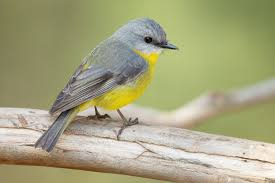

Carregando: imagens\kitchen.jpeg


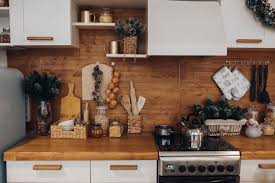

Carregando: imagens\pizza.jpeg


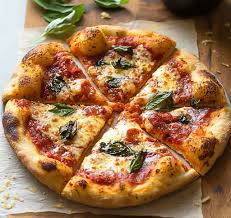

In [3]:
pasta_imagens = 'imagens'
arquivos_na_pasta = os.listdir(pasta_imagens)
arquivos_imagem = [arq for arq in arquivos_na_pasta if arq.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

imagens_carregadas = []

if arquivos_imagem:
    print(f"{len(arquivos_imagem)} imagens encontradas.")
    for arq in arquivos_imagem:
        caminho_imagem = os.path.join(pasta_imagens, arq)
        print(f"Carregando: {caminho_imagem}")
        
        # Carrega e exibe a imagem no notebook
        img = Image.open(caminho_imagem)
        imagens_carregadas.append((arq, img))
        display(img)
else:
    print("Nenhuma imagem encontrada na pasta 'imagens'. Adicione uma para prosseguir.")

## Enviando a Imagem para o Gemini

Agora vamos enviar a imagem e uma instrução de texto para que o modelo processe.

In [4]:
if imagens_carregadas:
    prompt = "Descreva esta imagem em detalhes. O que podemos ver nela?"
    
    for nome_arquivo, imagem in imagens_carregadas:
        print(f"\n--- Analisando arquivo: {nome_arquivo} ---")
        print("Enviando para o Gemini...")
        
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[imagem, prompt]
        )
        
        print("\nResposta:")
        print(response.text)
else:
    print("Carregue as imagens primeiro!")


--- Analisando arquivo: bird.jpeg ---
Enviando para o Gemini...

Resposta:
A imagem mostra um **pássaro pequeno e vibrante** empoleirado em um galho de madeira, com um fundo desfocado que destaca o animal.

Detalhes do que podemos ver:

1.  **O Pássaro (Foco Principal):**
    *   **Cores:** O pássaro exibe uma combinação marcante de cores. A parte superior da cabeça, as costas e as asas são de um tom de **cinza suave e uniforme**. O peito e o abdômen são de um **amarelo brilhante e vibrante**, criando um contraste vívido com o cinza. A cauda, relativamente curta, parece ser de um cinza mais escuro, quase preta em algumas partes.
    *   **Características Físicas:**
        *   **Cabeça:** É pequena e arredondada, com o cinza se estendendo até a nuca.
        *   **Olhos:** São pequenos, redondos e pretos, com uma aparência alerta e penetrante.
        *   **Bico:** É pequeno, fino, pontiagudo e de cor preta.
        *   **Asas:** Estão dobradas rente ao corpo, exibindo as penas cinzen